In [135]:
import pandas as pd
import numpy as np

import sqlite3
import matplotlib.pyplot as plt
import _mysql_connector

from sqlalchemy import create_engine
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier


In [136]:
from pathlib import Path

csv_path = Path(r"C:\Users\scarl\Desktop\Recuperacao_credito\dados\base_recuperacao_credito_br.csv")
df = pd.read_csv(csv_path)

df.head()


,id_cliente,idade,estado,dias_atraso,valor_divida,score_credito,status,data_contato
0,1,60.0,RJ,28.0,1112.76,581.0,Pago,2025-04-25
1,2,28.0,MG,26.0,17079.14,858.0,Em Negociação,2025-10-30
2,3,47.0,PR,8.0,1230.03,523.0,Pago,2025-09-16
3,4,58.0,BA,6.0,14250.50,NaN,Acordo,2025-04-23
4,5,48.0,SP,150.0,7315.67,306.0,Pago,2025-12-24


In [137]:
df.info()

df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_cliente     60 non-null     int64  
 1   idade          59 non-null     float64
 2   estado         60 non-null     object 
 3   dias_atraso    59 non-null     float64
 4   valor_divida   59 non-null     float64
 5   score_credito  59 non-null     float64
 6   status         59 non-null     object 
 7   data_contato   59 non-null     object 
dtypes: float64(4), int64(1), object(3)
memory usage: 3.9+ KB


id_cliente       0
idade            1
estado           0
dias_atraso      1
valor_divida     1
score_credito    1
status           1
data_contato     1
dtype: int64

In [138]:
df.fillna(df.median(numeric_only=True), inplace=True)

df.fillna("Não informado", inplace=True)

df["pagou"] = df["status"].apply(
    lambda x: "Sim" if x== "Pago" else "Não"
)

df["pagou"].value_counts(dropna=False)
df["status"].value_counts()
print(df[["status", "pagou"]].head(20))

len(df)

           status pagou
0            Pago   Sim
1   Em Negociação   Não
2            Pago   Sim
3          Acordo   Não
4            Pago   Sim
5    Inadimplente   Não
6        Cobrança   Não
7   Em Negociação   Não
8        Cobrança   Não
9    Inadimplente   Não
10   Inadimplente   Não
11  Em Negociação   Não
12           Pago   Sim
13           Pago   Sim
14   Inadimplente   Não
15   Inadimplente   Não
16           Pago   Sim
17   Inadimplente   Não
18           Pago   Sim
19           Pago   Sim


60

In [139]:
import sqlite3
from pathlib import Path

db_path = Path("..") / "recupera_credito.db"
con = sqlite3.connect(db_path)

In [140]:
df.to_sql(
    "clientes",
    con,
    if_exists="replace",
    index=False
)

60

In [141]:
consulta = "SELECT * FROM clientes LIMIT 10"
resultado = pd.read_sql(consulta, con)

In [142]:
consulta = """

SELECT
    estado,
    AVG(valor_divida) AS media

FROM clientes
GROUP BY estado
ORDER BY media DESC

"""
resultado = pd.read_sql(consulta, con)
resultado

,estado,media
0,PR,13868.175833
1,SP,12731.942500
2,BA,12458.555000
3,MG,12119.561667
4,RJ,10938.622500


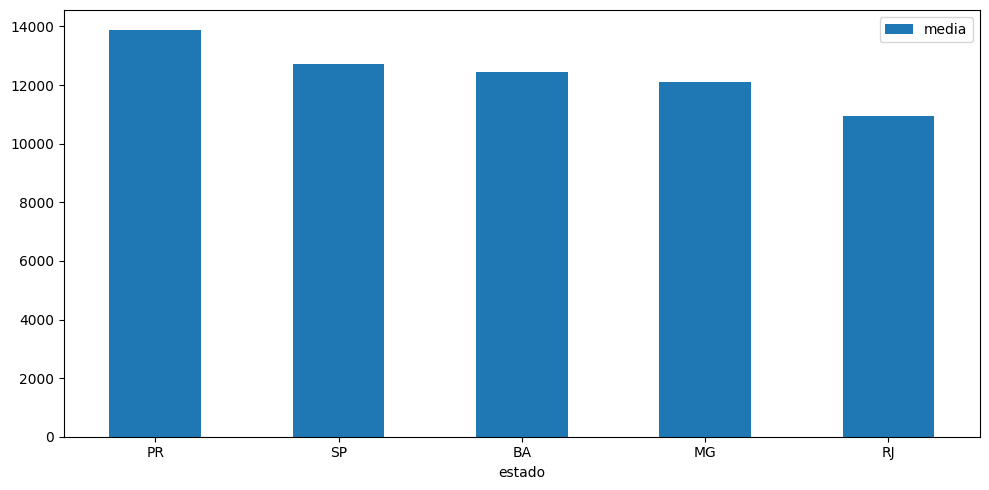

In [143]:
resultado.plot(
    x="estado",
    y="media",
    kind="bar",
    figsize=(10, 5),
    rot=0

)

plt.tight_layout()
plt.show()

In [144]:
print(df.columns.tolist())

['id_cliente', 'idade', 'estado', 'dias_atraso', 'valor_divida', 'score_credito', 'status', 'data_contato', 'pagou']


In [145]:
print(df.columns.tolist())

if "pagou" not in df.columns:
    # exemplo: criar a coluna alvo a partir de status
    df["pagou"] = df["status"].eq("pago").astype(int)

X = df.drop(columns=["pagou"])
y = df["pagou"]

['id_cliente', 'idade', 'estado', 'dias_atraso', 'valor_divida', 'score_credito', 'status', 'data_contato', 'pagou']


In [146]:
X = df.drop("pagou", axis=1)
y = df["pagou"]

In [147]:
encoder = LabelEncoder()

for coluna in X.select_dtypes(include="object"):
    X[coluna] = encoder.fit_transform(X[coluna])

In [148]:
X_train, X_test, y_train, y_test = train_test_split(

X,
y,
test_size=0.30,
random_state=42
)


In [149]:
modelo = DecisionTreeClassifier()
modelo.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [150]:
pred= modelo.predict(X_test)

In [151]:
accuracy_score(y_test, pred)

1.0

In [152]:
importancias = pd.DataFrame({
"Variavel": X.columns,
"Importancia":modelo.feature_importances_
})

importancias.sort_values(
"Importancia",
ascending=False
)

,Variavel,Importancia
6,status,1.0
0,id_cliente,0.0
2,estado,0.0
1,idade,0.0
3,dias_atraso,0.0
4,valor_divida,0.0
5,score_credito,0.0
7,data_contato,0.0


In [153]:
from pathlib import Path

output_path = Path(r"C:\Users\scarl\Desktop\Recuperacao_credito\dados\clientes_tratados.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(output_path, index=False, encoding="utf-8-sig")
print("Exportados")

Exportados
